In [ ]:
# Descargar y compilar TM-align (Solo necesitas correr esto una vez por sesión)
!wget https://zhanggroup.org/TM-align/TMalign.cpp
!g++ -static -O3 -ffast-math -lm -o TMalign TMalign.cpp
!chmod +x TMalign

--2026-04-15 22:50:44--  https://zhanggroup.org/TM-align/TMalign.cpp
Resolving zhanggroup.org (zhanggroup.org)... 104.21.13.194, 172.67.157.77, 2606:4700:3037::ac43:9d4d, ...
Connecting to zhanggroup.org (zhanggroup.org)|104.21.13.194|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://aideepmed.com/TM-align/TMalign.cpp [following]
--2026-04-15 22:50:45--  https://aideepmed.com/TM-align/TMalign.cpp
Resolving aideepmed.com (aideepmed.com)... 104.21.33.198, 172.67.149.27, 2606:4700:3037::6815:21c6, ...
Connecting to aideepmed.com (aideepmed.com)|104.21.33.198|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182099 (178K)
Saving to: ‘TMalign.cpp’

TMalign.cpp         100%[===================>] 177.83K   215KB/s    in 0.8s    

2026-04-15 22:50:46 (215 KB/s) - ‘TMalign.cpp’ saved [182099/182099]



In [ ]:
import os
import subprocess
import pandas as pd

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
carpeta_pdbs = "/content/drive/MyDrive/FAP-Project/PDBs_rank_1" # <-- PON TU RUTA
ruta_resultados = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes.csv"

# ==========================================
# 2. AGRUPAR LOS ARCHIVOS (LÓGICA CORREGIDA)
# ==========================================
grupos = {}

# Si no corriste la celda de instalación de TMalign antes en esta sesión,
# asegúrate de hacerlo para que el binario exista.
if not os.path.exists("./TMalign"):
    print("⚠️ ADVERTENCIA: No se encontró TMalign. Compilándolo rápido...")
    os.system("wget https://zhanggroup.org/TM-align/TMalign.cpp")
    os.system("g++ -static -O3 -ffast-math -lm -o TMalign TMalign.cpp")
    os.system("chmod +x TMalign")

print("1. Leyendo carpeta y agrupando variantes...")
for archivo in os.listdir(carpeta_pdbs):
    if not archivo.endswith(".pdb"): continue

    # Extraemos el prefijo (ej. '5BKH')
    prefijo = archivo.split("_")[0]

    if prefijo not in grupos:
        grupos[prefijo] = {}

    ruta_completa = os.path.join(carpeta_pdbs, archivo)

    # Cortamos toda la basura de AlphaFold para quedarnos con algo como "5BKH_Del_3"
    parte_izquierda = archivo.split("_unrelaxed")[0]

    if "_WT_" in archivo:
        grupos[prefijo]['WT'] = ruta_completa
    else:
        # Quitamos el "5BKH_" del inicio para que solo nos quede "Del_3", "Mut_40", etc.
        nombre_variante = parte_izquierda.replace(prefijo + "_", "")
        grupos[prefijo][nombre_variante] = ruta_completa

# ==========================================
# 3. FUNCIÓN PARA CORRER TM-ALIGN
# ==========================================
def comparar_estructuras(pdb_base, pdb_variante):
    """Corre TM-align y extrae el RMSD y TM-score."""
    comando = f"./TMalign '{pdb_base}' '{pdb_variante}'"
    resultado = subprocess.run(comando, shell=True, capture_output=True, text=True)

    rmsd = None
    tm_score = None

    for linea in resultado.stdout.split('\n'):
        if linea.startswith("Aligned length="):
            partes = linea.split(',')
            rmsd = float(partes[1].split('=')[1].strip())
        elif linea.startswith("TM-score=") and "normalized by length of Chain_1" in linea:
            tm_score = float(linea.split('=')[1].split('(')[0].strip())

    return rmsd, tm_score

# ==========================================
# 4. EJECUTAR COMPARACIONES
# ==========================================
datos_finales = []
print(f" -> Encontrados {len(grupos)} grupos de proteínas.")
print("2. Corriendo alineamientos estructurales (esto tomará unos minutos)...")

for prefijo, variantes in grupos.items():
    if 'WT' not in variantes:
        print(f"   -> Saltando {prefijo}: No se encontró archivo WT.")
        continue

    pdb_wt = variantes['WT']

    # Iteramos sobre todas las variantes que no sean la WT
    for nombre_variante, ruta_variante in variantes.items():
        if nombre_variante == 'WT': continue

        rmsd, tm_score = comparar_estructuras(pdb_wt, ruta_variante)

        # Extraemos si es "Mut" o "Del" y el porcentaje/cantidad para tener datos más limpios
        tipo = nombre_variante.split("_")[0] # "Mut" o "Del"
        cantidad = nombre_variante.split("_")[1] if "_" in nombre_variante else "N/A"

        datos_finales.append({
            'Proteina': prefijo,
            'Variante_Completa': nombre_variante,
            'Tipo_Variante': tipo,
            'Magnitud': cantidad,
            'RMSD': rmsd,
            'TM_Score': tm_score
        })

# ==========================================
# 5. GUARDAR RESULTADOS
# ==========================================
print("\n3. Guardando CSV actualizado...")
df_resultados = pd.DataFrame(datos_finales)

# Ordenamos la tabla para que se vea bonita (por Proteína y Tipo)
df_resultados = df_resultados.sort_values(by=['Proteina', 'Tipo_Variante', 'Magnitud'])

df_resultados.to_csv(ruta_resultados, index=False)

print("\n" + "="*50)
print("¡LISTO! Tabla generada con éxito.")
print("="*50)
display(df_resultados.head(15))

1. Leyendo carpeta y agrupando variantes...
 -> Encontrados 59 grupos de proteínas.
2. Corriendo alineamientos estructurales (esto tomará unos minutos)...

3. Guardando CSV actualizado...

¡LISTO! Tabla generada con éxito.


,Proteina,Variante_Completa,Tipo_Variante,Magnitud,RMSD,TM_Score
330,10DC,Del_10,Del,10,2.07,0.78899
332,10DC,Del_3,Del,3,0.84,0.94514
331,10DC,Del_5,Del,5,1.08,0.90590
333,10DC,Mut_10,Mut,10,1.04,0.95922
334,10DC,Mut_40,Mut,40,2.26,0.82325
335,10DC,Mut_70,Mut,70,5.56,0.23587
60,10JX,Del_10,Del,10,3.60,0.43729
62,10JX,Del_3,Del,3,2.04,0.70076
61,10JX,Del_5,Del,5,2.10,0.66542
63,10JX,Mut_10,Mut,10,1.56,0.78778


In [ ]:
import pandas as pd
import os

# ==========================================
# 1. RUTAS DE TUS ARCHIVOS
# ==========================================
# La tabla que acabas de generar en el paso anterior
ruta_csv_variantes = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes.csv"

# Tus FASTA originales
ruta_fasta_novel = "/content/drive/MyDrive/FAP-Project/Experimento_Novel_Reducido.fasta"
ruta_fasta_similares = "/content/drive/MyDrive/FAP-Project/Experimento_Similares_Reducido.fasta"

# Ruta para guardar la tabla ya con su etiqueta
ruta_csv_final = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes_Etiquetado.csv"

# ==========================================
# 2. FUNCIÓN PARA LEER FASTAS
# ==========================================
def obtener_nombres_fasta(ruta):
    """Extrae solo los nombres (headers) de un archivo FASTA."""
    nombres = []
    if not os.path.exists(ruta):
        print(f"  -> AVISO: No se encontró el archivo {ruta}")
        return nombres

    with open(ruta, 'r') as f:
        for linea in f:
            linea = linea.strip()
            if linea.startswith(">"):
                # Guardamos el nombre sin el '>'
                nombres.append(linea[1:])
    return nombres

# ==========================================
# 3. PROCESO DE ETIQUETADO
# ==========================================
print("1. Extrayendo clasificaciones de los FASTA originales...")
nombres_novel = obtener_nombres_fasta(ruta_fasta_novel)
nombres_similares = obtener_nombres_fasta(ruta_fasta_similares)

print(f"   -> Encontradas {len(nombres_novel)} proteínas Novel.")
print(f"   -> Encontradas {len(nombres_similares)} proteínas Similares.")

print("\n2. Leyendo tabla de variantes y asignando etiquetas...")
df = pd.read_csv(ruta_csv_variantes)

def asignar_etiqueta(proteina):
    proteina = str(proteina)

    # Buscar en la lista de Novel
    for nombre_fasta in nombres_novel:
        # Buscamos si el prefijo (ej. '5BKH') está en el nombre del FASTA
        if proteina in nombre_fasta or nombre_fasta.startswith(proteina):
            return "Novel"

    # Buscar en la lista de Similares
    for nombre_fasta in nombres_similares:
        if proteina in nombre_fasta or nombre_fasta.startswith(proteina):
            return "Similar"

    return "No_Encontrado"

# Creamos la nueva columna
df['Clasificacion_Original'] = df['Proteina'].apply(asignar_etiqueta)

# Contar para verificar que todo salió bien
conteo = df['Clasificacion_Original'].value_counts()

# ==========================================
# 4. GUARDAR RESULTADOS
# ==========================================
print("\n3. Guardando CSV final etiquetado...")
df.to_csv(ruta_csv_final, index=False)

print("\n" + "="*50)
print("¡LISTO! Tabla etiquetada con éxito.")
print("Resumen de variantes por grupo (recuerda que hay 6 variantes por proteína):")
for etiqueta, cantidad in conteo.items():
    print(f"  - {etiqueta}: {cantidad} filas")
print("="*50)

# Mostramos una muestra
display(df.head(15))

1. Extrayendo clasificaciones de los FASTA originales...
   -> Encontradas 210 proteínas Novel.
   -> Encontradas 210 proteínas Similares.

2. Leyendo tabla de variantes y asignando etiquetas...

3. Guardando CSV final etiquetado...

¡LISTO! Tabla etiquetada con éxito.
Resumen de variantes por grupo (recuerda que hay 6 variantes por proteína):
  - Novel: 180 filas
  - Similar: 174 filas


,Proteina,Variante_Completa,Tipo_Variante,Magnitud,RMSD,TM_Score,Clasificacion_Original
0,10DC,Del_10,Del,10,2.07,0.78899,Similar
1,10DC,Del_3,Del,3,0.84,0.94514,Similar
2,10DC,Del_5,Del,5,1.08,0.90590,Similar
3,10DC,Mut_10,Mut,10,1.04,0.95922,Similar
4,10DC,Mut_40,Mut,40,2.26,0.82325,Similar
5,10DC,Mut_70,Mut,70,5.56,0.23587,Similar
6,10JX,Del_10,Del,10,3.60,0.43729,Novel
7,10JX,Del_3,Del,3,2.04,0.70076,Novel
8,10JX,Del_5,Del,5,2.10,0.66542,Novel
9,10JX,Mut_10,Mut,10,1.56,0.78778,Novel


In [ ]:
import os
import subprocess
import pandas as pd

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
# PON AQUÍ LA RUTA DE LA CARPETA PRINCIPAL (la que tiene las 60 subcarpetas)
carpeta_esmfold = "/content/drive/MyDrive/FAP-Project/esm_results"

# Dónde guardaremos el nuevo CSV de ESMFold
ruta_resultados_esm = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes_ESMFold.csv"

# ==========================================
# 2. BÚSQUEDA RECURSIVA (OS.WALK) Y AGRUPACIÓN
# ==========================================
grupos = {}

print("1. Escaneando subcarpetas de ESMFold...")

# os.walk entra a todas las subcarpetas automáticamente
for raiz, directorios, archivos in os.walk(carpeta_esmfold):
    for archivo in archivos:
        if not archivo.endswith(".pdb"):
            continue # Ignoramos los .txt

        # Obtenemos la ruta completa del archivo
        ruta_completa = os.path.join(raiz, archivo)

        # Extraemos el prefijo (ej. '5BKH')
        prefijo = archivo.split("_")[0]

        if prefijo not in grupos:
            grupos[prefijo] = {}

        # Dependiendo de cómo se llame tu archivo en ESMFold, extraemos el nombre de la variante.
        # ESMFold no pone "_unrelaxed_rank_001...", así que la limpieza es diferente.
        # Vamos a quitarle el ".pdb" y el prefijo para quedarnos con "WT" o "Del_3"
        nombre_limpio = archivo.replace(".pdb", "")

        if "_WT" in archivo:
            grupos[prefijo]['WT'] = ruta_completa
        else:
            # Quitamos el prefijo (ej. "5BKH_") para que quede "Del_3" o "Mut_10"
            nombre_variante = nombre_limpio.replace(prefijo + "_", "")
            grupos[prefijo][nombre_variante] = ruta_completa

print(f" -> Se encontraron {len(grupos)} grupos de proteínas.")

# ==========================================
# 3. FUNCIÓN DE TM-ALIGN
# ==========================================
def comparar_estructuras(pdb_base, pdb_variante):
    comando = f"./TMalign '{pdb_base}' '{pdb_variante}'"
    resultado = subprocess.run(comando, shell=True, capture_output=True, text=True)

    rmsd, tm_score = None, None
    for linea in resultado.stdout.split('\n'):
        if linea.startswith("Aligned length="):
            partes = linea.split(',')
            rmsd = float(partes[1].split('=')[1].strip())
        elif linea.startswith("TM-score=") and "normalized by length of Chain_1" in linea:
            tm_score = float(linea.split('=')[1].split('(')[0].strip())

    return rmsd, tm_score

# ==========================================
# 4. EJECUTAR COMPARACIONES
# ==========================================
datos_finales = []
print("2. Corriendo alineamientos estructurales para ESMFold...")

for prefijo, variantes in grupos.items():
    if 'WT' not in variantes:
        print(f"   -> Saltando {prefijo}: No se encontró archivo WT.")
        continue

    pdb_wt = variantes['WT']

    for nombre_variante, ruta_variante in variantes.items():
        if nombre_variante == 'WT': continue

        rmsd, tm_score = comparar_estructuras(pdb_wt, ruta_variante)

        tipo = nombre_variante.split("_")[0] if "_" in nombre_variante else "Desconocido"
        cantidad = nombre_variante.split("_")[1] if "_" in nombre_variante else "N/A"

        datos_finales.append({
            'Proteina': prefijo,
            'Variante_Completa': nombre_variante,
            'Tipo_Variante': tipo,
            'Magnitud': cantidad,
            'RMSD': rmsd,
            'TM_Score': tm_score
        })

# ==========================================
# 5. GUARDAR RESULTADOS
# ==========================================
print("\n3. Guardando CSV de ESMFold...")
df_resultados = pd.DataFrame(datos_finales)
df_resultados = df_resultados.sort_values(by=['Proteina', 'Tipo_Variante', 'Magnitud'])
df_resultados.to_csv(ruta_resultados_esm, index=False)

print("\n¡LISTO! Muestra de la tabla ESMFold:")
display(df_resultados.head(10))

1. Escaneando subcarpetas de ESMFold...
 -> Se encontraron 60 grupos de proteínas.
2. Corriendo alineamientos estructurales para ESMFold...
   -> Saltando 6KLP: No se encontró archivo WT.
   -> Saltando 6HKQ: No se encontró archivo WT.

3. Guardando CSV de ESMFold...

¡LISTO! Muestra de la tabla ESMFold:


,Proteina,Variante_Completa,Tipo_Variante,Magnitud,RMSD,TM_Score
11,10AF,Del_10,Del,10,2.57,0.75328
9,10AF,Del_3,Del,3,1.41,0.90170
10,10AF,Del_5,Del,5,1.40,0.88578
6,10AF,Mut_10,Mut,10,0.89,0.96900
7,10AF,Mut_40,Mut,40,2.98,0.74793
8,10AF,Mut_70,Mut,70,5.35,0.26674
137,10DC,Del_10,Del,10,1.99,0.79634
135,10DC,Del_3,Del,3,0.91,0.94237
136,10DC,Del_5,Del,5,1.41,0.86931
132,10DC,Mut_10,Mut,10,0.44,0.99205


In [ ]:
import pandas as pd
import os

# ==========================================
# 1. RUTAS DE TUS ARCHIVOS (Ajustadas para ESMFold)
# ==========================================
# La tabla que generaste en el paso anterior para ESMFold
ruta_csv_esmfold = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes_ESMFold.csv"

# Tus FASTA originales (estos no cambian)
ruta_fasta_novel = "/content/drive/MyDrive/FAP-Project/Experimento_Novel_Reducido.fasta"
ruta_fasta_similares = "/content/drive/MyDrive/FAP-Project/Experimento_Similares_Reducido.fasta"

# Ruta para guardar la tabla de ESMFold ya etiquetada
ruta_csv_final_esm = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes_ESMFold_Etiquetado.csv"

# ==========================================
# 2. FUNCIÓN PARA LEER FASTAS
# ==========================================
def obtener_nombres_fasta(ruta):
    nombres = []
    if not os.path.exists(ruta):
        print(f"  -> AVISO: No se encontró el archivo {ruta}")
        return nombres

    with open(ruta, 'r') as f:
        for linea in f:
            linea = linea.strip()
            if linea.startswith(">"):
                nombres.append(linea[1:])
    return nombres

# ==========================================
# 3. PROCESO DE ETIQUETADO
# ==========================================
print("1. Cargando clasificaciones de los FASTA...")
nombres_novel = obtener_nombres_fasta(ruta_fasta_novel)
nombres_similares = obtener_nombres_fasta(ruta_fasta_similares)

print(f"2. Leyendo tabla de ESMFold: {os.path.basename(ruta_csv_esmfold)}")
df_esm = pd.read_csv(ruta_csv_esmfold)

def asignar_etiqueta(proteina):
    proteina = str(proteina)
    # Buscar en Novel
    for nombre_fasta in nombres_novel:
        if proteina in nombre_fasta or nombre_fasta.startswith(proteina):
            return "Novel"
    # Buscar en Similares
    for nombre_fasta in nombres_similares:
        if proteina in nombre_fasta or nombre_fasta.startswith(proteina):
            return "Similar"
    return "No_Encontrado"

# Aplicar la etiqueta
df_esm['Clasificacion_Original'] = df_esm['Proteina'].apply(asignar_etiqueta)

# ==========================================
# 4. GUARDAR Y VERIFICAR
# ==========================================
df_esm.to_csv(ruta_csv_final_esm, index=False)

print("\n" + "="*50)
print("¡ETIQUETADO DE ESMFOLD COMPLETADO!")
print("="*50)
print(df_esm['Clasificacion_Original'].value_counts())
print("-" * 30)
display(df_esm.head(10))

1. Cargando clasificaciones de los FASTA...
2. Leyendo tabla de ESMFold: Comparacion_WT_vs_Variantes_ESMFold.csv

¡ETIQUETADO DE ESMFOLD COMPLETADO!
Clasificacion_Original
Similar    174
Novel      174
Name: count, dtype: int64
------------------------------


,Proteina,Variante_Completa,Tipo_Variante,Magnitud,RMSD,TM_Score,Clasificacion_Original
0,10AF,Del_10,Del,10,2.57,0.75328,Similar
1,10AF,Del_3,Del,3,1.41,0.90170,Similar
2,10AF,Del_5,Del,5,1.40,0.88578,Similar
3,10AF,Mut_10,Mut,10,0.89,0.96900,Similar
4,10AF,Mut_40,Mut,40,2.98,0.74793,Similar
5,10AF,Mut_70,Mut,70,5.35,0.26674,Similar
6,10DC,Del_10,Del,10,1.99,0.79634,Similar
7,10DC,Del_3,Del,3,0.91,0.94237,Similar
8,10DC,Del_5,Del,5,1.41,0.86931,Similar
9,10DC,Mut_10,Mut,10,0.44,0.99205,Similar


1. Cargando y combinando tablas...
 -> Tabla maestra guardada en: /content/drive/MyDrive/FAP-Project/Comparacion_Final_AF_vs_ESM.csv
2. Generando gráfica comparativa...


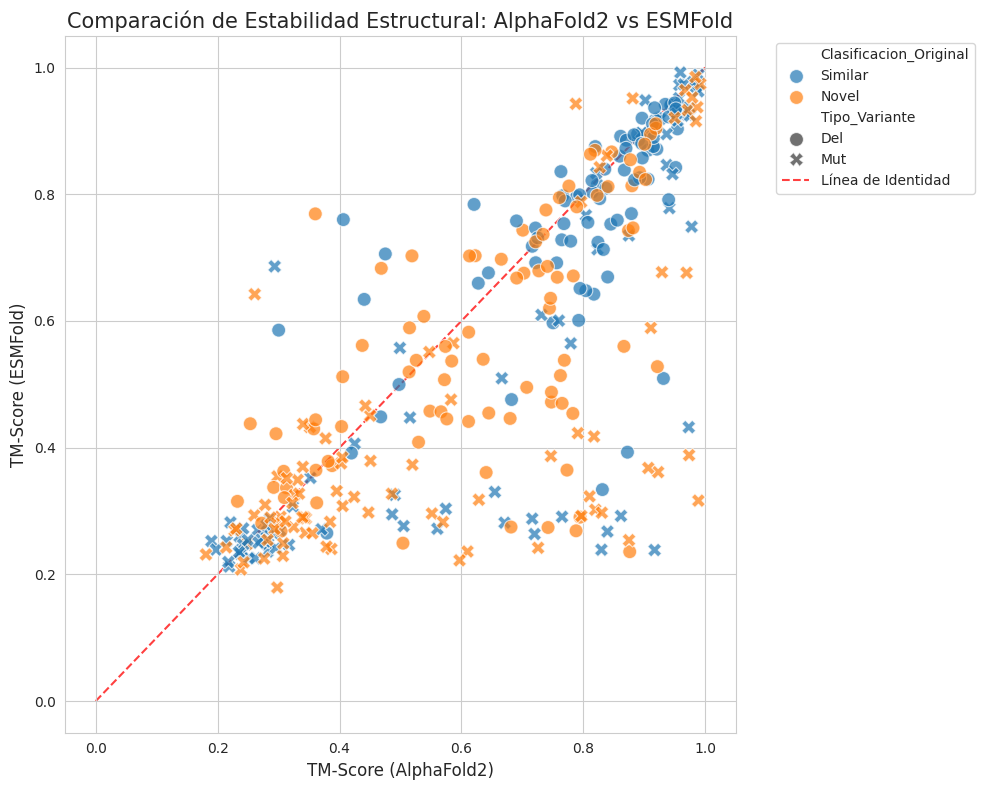


📊 ANÁLISIS DE CONSISTENCIA
Correlación general entre modelos: 0.7709

Promedio de TM-Score por categoría:
                        TM_Score_AF  TM_Score_ESM
Clasificacion_Original                           
Novel                      0.590455      0.495414
Similar                    0.701614      0.638147


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. RUTAS DE LOS ARCHIVOS ETIQUETADOS
# ==========================================
ruta_af = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes_Etiquetado.csv"
ruta_esm = "/content/drive/MyDrive/FAP-Project/Comparacion_WT_vs_Variantes_ESMFold_Etiquetado.csv"
ruta_union = "/content/drive/MyDrive/FAP-Project/Comparacion_Final_AF_vs_ESM.csv"

# ==========================================
# 2. CARGA Y UNIÓN DE DATOS
# ==========================================
print("1. Cargando y combinando tablas...")
df_af = pd.read_csv(ruta_af)
df_esm = pd.read_csv(ruta_esm)

# Unimos las tablas usando las columnas comunes
# Usamos suffixes para diferenciar los resultados de cada modelo
df_total = pd.merge(
    df_af,
    df_esm[['Proteina', 'Variante_Completa', 'RMSD', 'TM_Score']],
    on=['Proteina', 'Variante_Completa'],
    suffixes=('_AF', '_ESM')
)

# Guardar la tabla maestra
df_total.to_csv(ruta_union, index=False)
print(f" -> Tabla maestra guardada en: {ruta_union}")

# ==========================================
# 3. VISUALIZACIÓN: AF vs ESM (TM-Score)
# ==========================================
print("2. Generando gráfica comparativa...")

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Graficamos con colores según la clasificación (Novel vs Similar)
scatter = sns.scatterplot(
    data=df_total,
    x='TM_Score_AF',
    y='TM_Score_ESM',
    hue='Clasificacion_Original',
    style='Tipo_Variante',
    alpha=0.7,
    s=100
)

# Añadimos una línea diagonal (donde AF = ESM)
lims = [0, 1]
plt.plot(lims, lims, '--r', alpha=0.75, zorder=0, label='Línea de Identidad')

plt.title('Comparación de Estabilidad Estructural: AlphaFold2 vs ESMFold', fontsize=15)
plt.xlabel('TM-Score (AlphaFold2)', fontsize=12)
plt.ylabel('TM-Score (ESMFold)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()

# Guardar la gráfica
plt.savefig("/content/drive/MyDrive/FAP-Project/Grafica_Comparativa_Modelos.png", dpi=300)
plt.show()

# ==========================================
# 4. ESTADÍSTICAS RÁPIDAS
# ==========================================
correlacion = df_total['TM_Score_AF'].corr(df_total['TM_Score_ESM'])
print("\n" + "="*50)
print(f"📊 ANÁLISIS DE CONSISTENCIA")
print("="*50)
print(f"Correlación general entre modelos: {correlacion:.4f}")

# Diferencia promedio por grupo
resumen = df_total.groupby('Clasificacion_Original')[['TM_Score_AF', 'TM_Score_ESM']].mean()
print("\nPromedio de TM-Score por categoría:")
print(resumen)

Generando 1. Curvas de Supervivencia...


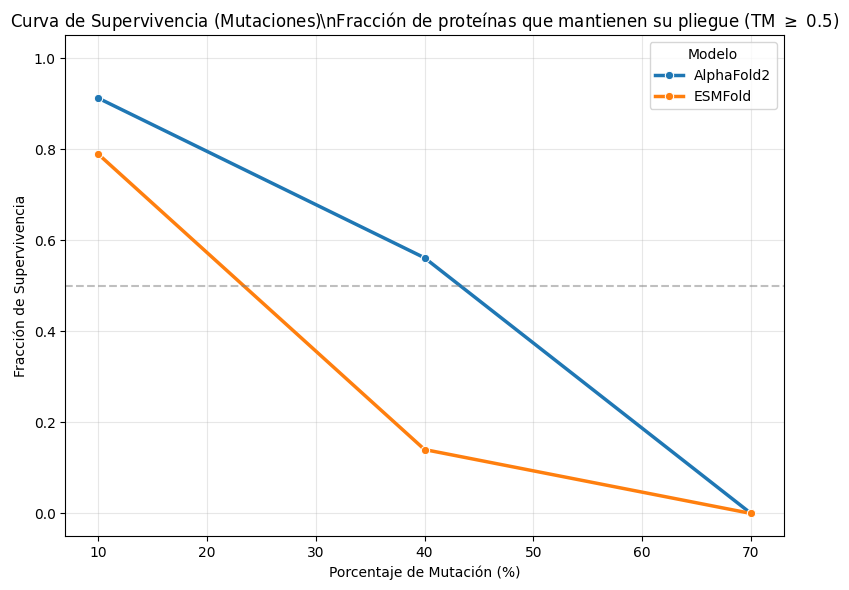

Generando 2. Gráficos de Violín...


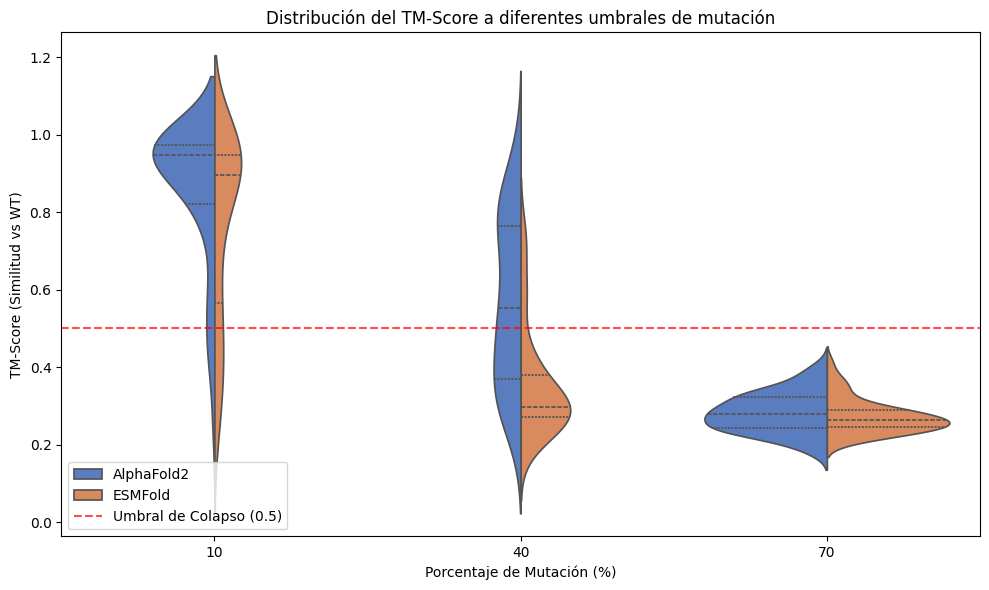

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
ruta_union = "/content/drive/MyDrive/FAP-Project/Comparacion_Final_AF_vs_ESM.csv"
df = pd.read_csv(ruta_union)

# Filtrar datos sucios si los hay y convertir Magnitud a número (para que se ordene bien 5, 10, 40...)
df = df[df['Magnitud'] != 'N/A'].copy()
df['Magnitud'] = pd.to_numeric(df['Magnitud'])

# Para facilitar las gráficas, vamos a "derretir" (melt) la tabla.
# En lugar de tener TM_Score_AF y TM_Score_ESM en columnas separadas,
# tendremos una columna 'Modelo' y una 'TM_Score'.

# Melt TM_Score columns
df_melted_tm = pd.melt(
    df,
    id_vars=['Proteina', 'Tipo_Variante', 'Magnitud', 'Clasificacion_Original'],
    value_vars=['TM_Score_AF', 'TM_Score_ESM'],
    var_name='Modelo_TM', # Temporary column to map model names
    value_name='TM_Score'
)
df_melted_tm['Modelo'] = df_melted_tm['Modelo_TM'].replace({'TM_Score_AF': 'AlphaFold2', 'TM_Score_ESM': 'ESMFold'})

# Melt pLDDT columns
df_melted_plddt = pd.melt(
    df,
    id_vars=['Proteina', 'Tipo_Variante', 'Magnitud', 'Clasificacion_Original'],
    value_vars=['pLDDT_AF', 'pLDDT_ESM'],
    var_name='Modelo_pLDDT', # Temporary column to map model names
    value_name='pLDDT'
)
df_melted_plddt['Modelo'] = df_melted_plddt['Modelo_pLDDT'].replace({'pLDDT_AF': 'AlphaFold2', 'pLDDT_ESM': 'ESMFold'})

# Merge the two melted dataframes on common identifying columns and the 'Modelo' column
df_melted = pd.merge(
    df_melted_tm[['Proteina', 'Tipo_Variante', 'Magnitud', 'Clasificacion_Original', 'Modelo', 'TM_Score']],
    df_melted_plddt[['Proteina', 'Tipo_Variante', 'Magnitud', 'Clasificacion_Original', 'Modelo', 'pLDDT']],
    on=['Proteina', 'Tipo_Variante', 'Magnitud', 'Clasificacion_Original', 'Modelo'],
    how='outer' # Use outer merge to ensure all rows are kept even if some pLDDTs are NaN
)

# Vamos a enfocarnos en las MUTACIONES para estos gráficos (puedes cambiar a 'Del' después)
df_mut = df_melted[df_melted['Tipo_Variante'] == 'Mut'].copy()

# ==========================================
# ANÁLISIS 1: CURVAS DE SUPERVIVENCIA
# ==========================================
print("Generando 1. Curvas de Supervivencia...")
# Calculamos la fracción de proteínas con TM-score >= 0.5
supervivencia = df_mut.groupby(['Magnitud', 'Modelo']).apply(
    lambda x: (x['TM_Score'] >= 0.5).mean(), include_groups=False
).reset_index(name='Fraccion_Supervivencia')

plt.figure(figsize=(8, 6))
sns.lineplot(data=supervivencia, x='Magnitud', y='Fraccion_Supervivencia', hue='Modelo', marker='o', linewidth=2.5)
plt.axhline(0.5, ls='--', color='gray', alpha=0.5) # Línea del 50%
plt.title(r'Curva de Supervivencia (Mutaciones)\nFracción de proteínas que mantienen su pliegue (TM $\geq$ 0.5)')
plt.xlabel('Porcentaje de Mutación (%)')
plt.ylabel('Fracción de Supervivencia')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS 2: GRÁFICOS DE VIOLÍN
# ==========================================
print("Generando 2. Gráficos de Violín...")
plt.figure(figsize=(10, 6))
# Usamos split=True para poner AF2 de un lado y ESMFold del otro en el mismo violín
sns.violinplot(data=df_mut, x='Magnitud', y='TM_Score', hue='Modelo', split=True, inner="quartile", palette="muted")
plt.axhline(0.5, ls='--', color='red', alpha=0.7, label='Umbral de Colapso (0.5)')
plt.title('Distribución del TM-Score a diferentes umbrales de mutación')
plt.xlabel('Porcentaje de Mutación (%)')
plt.ylabel('TM-Score (Similitud vs WT)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


Generando 1. Curvas de Supervivencia (Deleciones)...


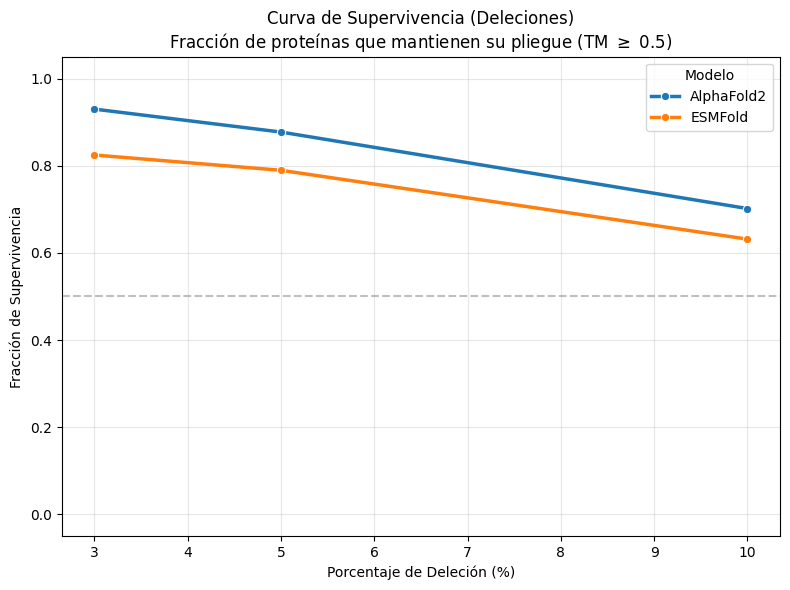

Generando 2. Gráficos de Violín (Deleciones)...


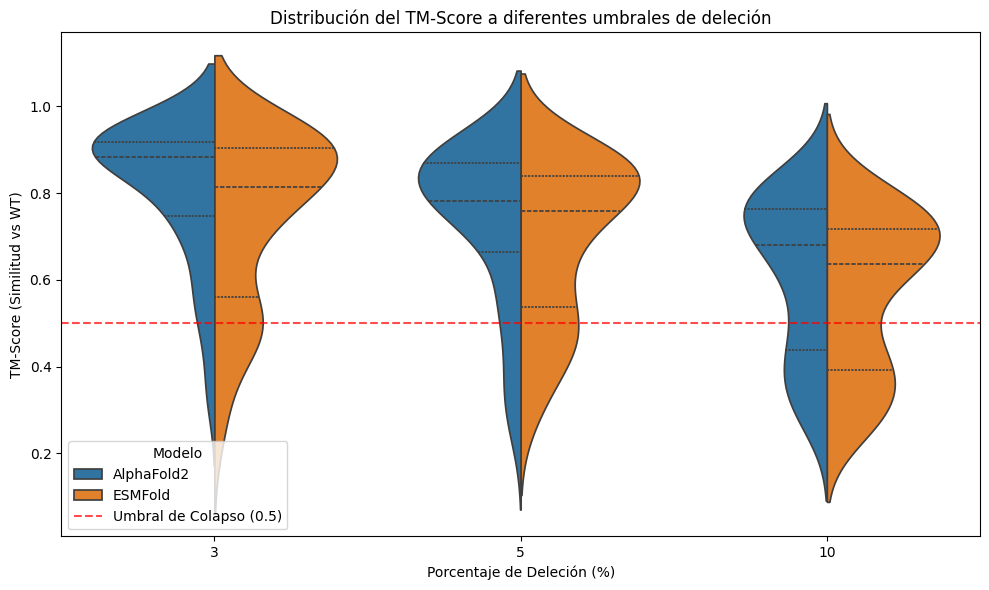

In [14]:
# ==========================================
# FILTRAR PARA DELECIONES
# ==========================================
# Nos enfocamos solo en el daño por deleción
df_del = df_melted[df_melted['Tipo_Variante'] == 'Del'].copy()

# ==========================================
# ANÁLISIS 1: CURVAS DE SUPERVIVENCIA (DELECIONES)
# ==========================================
print("Generando 1. Curvas de Supervivencia (Deleciones)...")
# Calculamos la fracción de proteínas con TM-score >= 0.5
supervivencia_del = df_del.groupby(['Magnitud', 'Modelo']).apply(
    lambda x: (x['TM_Score'] >= 0.5).mean(), include_groups=False
).reset_index(name='Fraccion_Supervivencia')

plt.figure(figsize=(8, 6))
# Agregué los colores consistentes (Azul y Naranja) para que combine con el resto de tu reporte
sns.lineplot(data=supervivencia_del, x='Magnitud', y='Fraccion_Supervivencia', hue='Modelo',
             marker='o', linewidth=2.5, palette={"AlphaFold2": "#1f77b4", "ESMFold": "#ff7f0e"})
plt.axhline(0.5, ls='--', color='gray', alpha=0.5) # Línea del 50%
plt.title(r'Curva de Supervivencia (Deleciones)' + '\n' + r'Fracción de proteínas que mantienen su pliegue (TM $\geq$ 0.5)')
plt.xlabel('Porcentaje de Deleción (%)') # ¡Cambio de etiqueta!
plt.ylabel('Fracción de Supervivencia')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS 2: GRÁFICOS DE VIOLÍN (DELECIONES)
# ==========================================
print("Generando 2. Gráficos de Violín (Deleciones)...")
plt.figure(figsize=(10, 6))
# Violín con los colores correctos
sns.violinplot(data=df_del, x='Magnitud', y='TM_Score', hue='Modelo', split=True,
               inner="quartile", palette={"AlphaFold2": "#1f77b4", "ESMFold": "#ff7f0e"})
plt.axhline(0.5, ls='--', color='red', alpha=0.7, label='Umbral de Colapso (0.5)')
plt.title('Distribución del TM-Score a diferentes umbrales de deleción')
plt.xlabel('Porcentaje de Deleción (%)') # ¡Cambio de etiqueta!
plt.ylabel('TM-Score (Similitud vs WT)')
plt.legend(loc='lower left', title="Modelo")
plt.tight_layout()
plt.show()

1. Cargando tabla maestra y extrayendo pLDDT...
 -> ¡Tabla maestra actualizada con valores correctos!

2. Calculando correlaciones (Solo Mutaciones)...
   AlphaFold2 - Pearson (Daño vs pLDDT): -0.7712 (p: 5.62e-35)
   ESMFold    - Pearson (Daño vs pLDDT): -0.7471 (p: 8.70e-32)

3. Generando las gráficas corregidas...


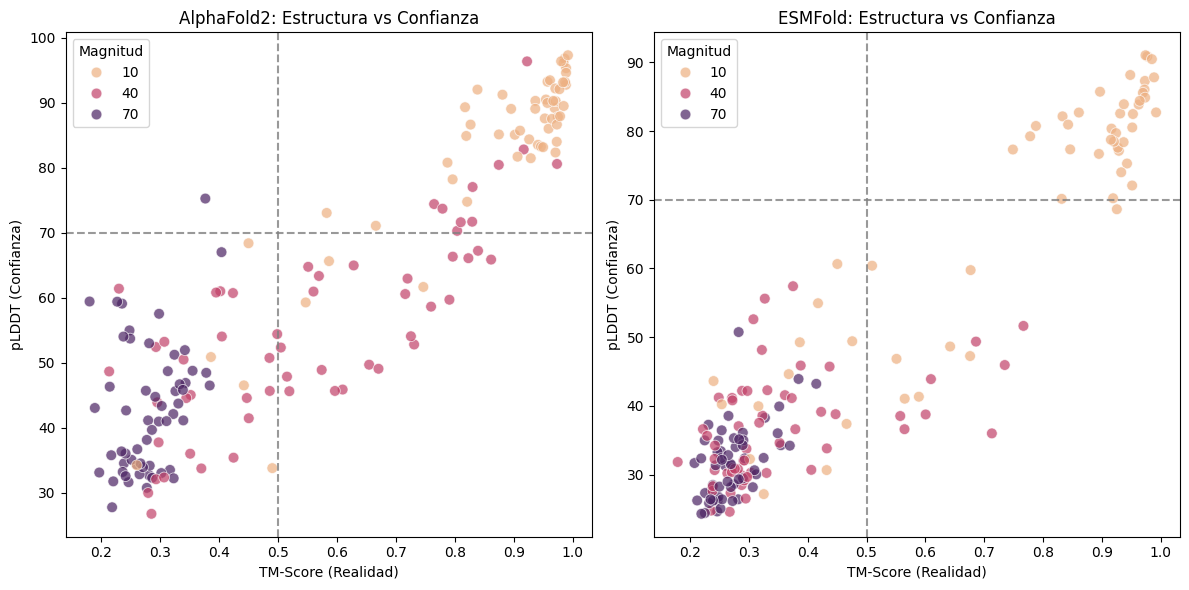

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
ruta_tabla_maestra = "/content/drive/MyDrive/FAP-Project/Comparacion_Final_AF_vs_ESM.csv"
carpeta_af = "/content/drive/MyDrive/FAP-Project/PDBs_rank_1"
carpeta_esm = "/content/drive/MyDrive/FAP-Project/esm_results"

# ==========================================
# 2. FUNCIONES DE EXTRACCIÓN
# ==========================================
def calcular_plddt_af(ruta_pdb):
    """Extrae el pLDDT estándar para AlphaFold2."""
    if not os.path.exists(ruta_pdb): return np.nan
    plddts = []
    with open(ruta_pdb, 'r') as f:
        for linea in f:
            if linea.startswith("ATOM  ") and " CA " in linea:
                try:
                    b_factor = float(linea[60:66].strip())
                    plddts.append(b_factor)
                except ValueError:
                    continue
    return sum(plddts) / len(plddts) if plddts else np.nan

def calcular_plddt_esm_robusto(ruta_pdb):
    """Extrae el pLDDT de ESMFold manejando espacios variables y escalas 0-1."""
    if not os.path.exists(ruta_pdb): return np.nan
    plddts = []
    with open(ruta_pdb, 'r') as f:
        for linea in f:
            if linea.startswith("ATOM  ") and " CA " in linea:
                partes = linea.split()
                nums = []
                for p in reversed(partes):
                    try:
                        nums.append(float(p))
                    except ValueError:
                        pass
                if len(nums) >= 2:
                    plddts.append(nums[0])

    if not plddts: return np.nan
    promedio = sum(plddts) / len(plddts)
    # Corrección de escala para ESMFold
    if promedio <= 1.0:
        promedio *= 100
    return promedio

# ==========================================
# 3. EXTRACCIÓN DE DATOS Y ACTUALIZACIÓN
# ==========================================
print("1. Cargando tabla maestra y extrayendo pLDDT...")
df = pd.read_csv(ruta_tabla_maestra)

plddt_af_list = []
plddt_esm_list = []

for index, row in df.iterrows():
    proteina = row['Proteina']
    variante = row['Variante_Completa']

    # --- Búsqueda de AlphaFold ---
    if variante == "WT":
        nombre_af = f"{proteina}_WT_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000.pdb"
    else:
        nombre_af = None
        for f in os.listdir(carpeta_af):
            if f.startswith(f"{proteina}_{variante}_unrelaxed"):
                nombre_af = f
                break
    ruta_pdb_af = os.path.join(carpeta_af, nombre_af) if nombre_af else ""

    # --- Búsqueda de ESMFold ---
    ruta_pdb_esm = ""
    for raiz, _, archivos in os.walk(carpeta_esm):
        nombre_buscado = f"{proteina}_{variante}.pdb"
        if nombre_buscado in archivos:
            ruta_pdb_esm = os.path.join(raiz, nombre_buscado)
            break

    # Calcular y guardar
    plddt_af_list.append(calcular_plddt_af(ruta_pdb_af))
    plddt_esm_list.append(calcular_plddt_esm_robusto(ruta_pdb_esm))

# Sobreescribimos/añadimos las columnas y guardamos
df['pLDDT_AF'] = plddt_af_list
df['pLDDT_ESM'] = plddt_esm_list
df.to_csv(ruta_tabla_maestra, index=False)
print(" -> ¡Tabla maestra actualizada con valores correctos!")

# ==========================================
# 4. ANÁLISIS ESTADÍSTICO
# ==========================================
print("\n2. Calculando correlaciones (Solo Mutaciones)...")
df_mut = df[(df['Tipo_Variante'] == 'Mut') & (df['pLDDT_AF'].notna()) & (df['pLDDT_ESM'].notna())].copy()
df_mut['Magnitud'] = pd.to_numeric(df_mut['Magnitud'])

p_corr_af, p_val_af = pearsonr(df_mut['Magnitud'], df_mut['pLDDT_AF'])
p_corr_esm, p_val_esm = pearsonr(df_mut['Magnitud'], df_mut['pLDDT_ESM'])

print(f"   AlphaFold2 - Pearson (Daño vs pLDDT): {p_corr_af:.4f} (p: {p_val_af:.2e})")
print(f"   ESMFold    - Pearson (Daño vs pLDDT): {p_corr_esm:.4f} (p: {p_val_esm:.2e})")

# ==========================================
# 5. GRÁFICAS DE DISPERSIÓN
# ==========================================
print("\n3. Generando las gráficas corregidas...")
plt.figure(figsize=(12, 6))

# Subtrama 1: AlphaFold2
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_mut, x='TM_Score_AF', y='pLDDT_AF', hue='Magnitud', palette='flare', alpha=0.7, s=60)
plt.title('AlphaFold2: Estructura vs Confianza')
plt.xlabel('TM-Score (Realidad)')
plt.ylabel('pLDDT (Confianza)')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.8)
plt.axhline(70, color='gray', linestyle='--', alpha=0.8)

# Subtrama 2: ESMFold (Con los datos corregidos)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_mut, x='TM_Score_ESM', y='pLDDT_ESM', hue='Magnitud', palette='flare', alpha=0.7, s=60)
plt.title('ESMFold: Estructura vs Confianza')
plt.xlabel('TM-Score (Realidad)')
plt.ylabel('pLDDT (Confianza)')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.8)
plt.axhline(70, color='gray', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# 1. Cargar la tabla maestra
ruta_tabla_maestra = "/content/drive/MyDrive/FAP-Project/Comparacion_Final_AF_vs_ESM.csv"
df = pd.read_csv(ruta_tabla_maestra)

# Filtrar solo mutaciones para que coincida con las gráficas
df_mut = df[(df['pLDDT_AF'].notna()) & (df['pLDDT_ESM'].notna())].copy()

# ==========================================
# 2. DEFINIR LA ZONA DE ALUCINACIÓN (PELIGRO)
# ==========================================
# Criterios: Estructura colapsada (TM < 0.5) PERO confianza alta (pLDDT >= 70)

# Para AlphaFold2
alucinaciones_af = df_mut[(df_mut['TM_Score_AF'] < 0.5) & (df_mut['pLDDT_AF'] >= 70)]
total_colapsadas_af = df_mut[df_mut['TM_Score_AF'] < 0.5]

# Para ESMFold
alucinaciones_esm = df_mut[(df_mut['TM_Score_ESM'] < 0.5) & (df_mut['pLDDT_ESM'] >= 70)]
total_colapsadas_esm = df_mut[df_mut['TM_Score_ESM'] < 0.5]

# ==========================================
# 3. MOSTRAR RESULTADOS
# ==========================================
print("="*60)
print("🔍 ANÁLISIS DE 'ALUCINACIONES ESTRUCTURALES' (TM < 0.5 & pLDDT >= 70)")
print("="*60)

# Estadísticas AlphaFold2
if len(total_colapsadas_af) > 0:
    porcentaje_af = (len(alucinaciones_af) / len(total_colapsadas_af)) * 100
    print(f"🔸 ALPHAFOLD2:")
    print(f"   - Casos totales colapsados (TM < 0.5): {len(total_colapsadas_af)}")
    print(f"   - Casos en 'Zona de Peligro': {len(alucinaciones_af)}")
    print(f"   - Porcentaje de alucinación: {porcentaje_af:.1f}%\n")
else:
    print("🔸 ALPHAFOLD2: No hay estructuras colapsadas en los datos.\n")

# Estadísticas ESMFold
if len(total_colapsadas_esm) > 0:
    porcentaje_esm = (len(alucinaciones_esm) / len(total_colapsadas_esm)) * 100
    print(f"🔹 ESMFOLD:")
    print(f"   - Casos totales colapsados (TM < 0.5): {len(total_colapsadas_esm)}")
    print(f"   - Casos en 'Zona de Peligro': {len(alucinaciones_esm)}")
    print(f"   - Porcentaje de alucinación: {porcentaje_esm:.1f}%")
else:
    print("🔹 ESMFOLD: No hay estructuras colapsadas en los datos.")
print("="*60)

# Opcional: Mostrar cuáles fueron esas proteínas "rebeldes" de AlphaFold
print("\nEjemplo de las variantes que AlphaFold2 alucinó:")
display(alucinaciones_af[['Proteina', 'Variante_Completa', 'TM_Score_AF', 'pLDDT_AF']].head())

🔍 ANÁLISIS DE 'ALUCINACIONES ESTRUCTURALES' (TM < 0.5 & pLDDT >= 70)
🔸 ALPHAFOLD2:
   - Casos totales colapsados (TM < 0.5): 115
   - Casos en 'Zona de Peligro': 5
   - Porcentaje de alucinación: 4.3%

🔹 ESMFOLD:
   - Casos totales colapsados (TM < 0.5): 161
   - Casos en 'Zona de Peligro': 2
   - Porcentaje de alucinación: 1.2%

Ejemplo de las variantes que AlphaFold2 alucinó:


,Proteina,Variante_Completa,TM_Score_AF,pLDDT_AF
12,10PW,Del_10,0.47515,76.853096
151,6IVH,Del_3,0.36261,70.488197
204,6L0O,Del_10,0.38773,76.949028
239,6PQT,Mut_70,0.37714,75.263043
276,6TDN,Del_10,0.30404,78.155513


In [15]:
import pandas as pd

# 1. Separar datos (asegurándonos de incluir el WT / 0% como línea base)
df_mutaciones = df[df['Tipo_Variante'].isin(['WT', 'Mut'])].copy()
df_deleciones = df[df['Tipo_Variante'].isin(['WT', 'Del'])].copy()

df_mutaciones['Magnitud'] = df_mutaciones['Magnitud'].fillna(0).astype(int)
df_deleciones['Magnitud'] = df_deleciones['Magnitud'].fillna(0).astype(int)

# 2. Función para agrupar por Clasificación Y Magnitud
def generar_tabla_origen(df_subset, nombre_columna):
    tabla = df_subset.groupby(['Clasificacion_Original', 'Magnitud']).agg(
        N_Casos=('Proteina', 'count'),

        # AlphaFold2
        AF2_TM_Prom=('TM_Score_AF', 'mean'),
        AF2_TM_Rango=('TM_Score_AF', lambda x: f"{x.min():.2f} - {x.max():.2f}"),
        AF2_pLDDT=('pLDDT_AF', 'mean'),

        # ESMFold
        ESM_TM_Prom=('TM_Score_ESM', 'mean'),
        ESM_TM_Rango=('TM_Score_ESM', lambda x: f"{x.min():.2f} - {x.max():.2f}"),
        ESM_pLDDT=('pLDDT_ESM', 'mean')
    ).reset_index()

    # Formateo limpio a 2 decimales
    tabla = tabla.round(2)
    tabla.rename(columns={'Magnitud': nombre_columna, 'Clasificacion_Original': 'Origen Evolutivo'}, inplace=True)
    return tabla

# 3. Generar y mostrar las tablas
tabla_origen_mut = generar_tabla_origen(df_mutaciones, 'Mutación (%)')
tabla_origen_del = generar_tabla_origen(df_deleciones, 'Deleción (%)')

print("=== TABLA 3A: IMPACTO DE MUTACIONES POR ORIGEN EVOLUTIVO ===")
display(tabla_origen_mut)

print("\n=== TABLA 3B: IMPACTO DE DELECIONES POR ORIGEN EVOLUTIVO ===")
display(tabla_origen_del)

=== TABLA 3A: IMPACTO DE MUTACIONES POR ORIGEN EVOLUTIVO ===


,Origen Evolutivo,Mutación (%),N_Casos,AF2_TM_Prom,AF2_TM_Rango,AF2_pLDDT,ESM_TM_Prom,ESM_TM_Rango,ESM_pLDDT
0,Novel,10,29,0.80,0.26 - 0.99,79.49,0.67,0.24 - 0.98,61.81
1,Novel,40,29,0.52,0.21 - 0.97,56.08,0.31,0.18 - 0.44,39.71
2,Novel,70,29,0.31,0.18 - 0.40,48.78,0.29,0.21 - 0.41,35.11
3,Similar,10,28,0.93,0.49 - 0.99,86.25,0.86,0.33 - 0.99,76.39
4,Similar,40,28,0.61,0.28 - 0.92,55.13,0.40,0.24 - 0.77,33.68
5,Similar,70,28,0.26,0.19 - 0.32,36.54,0.25,0.21 - 0.31,28.32



=== TABLA 3B: IMPACTO DE DELECIONES POR ORIGEN EVOLUTIVO ===


,Origen Evolutivo,Deleción (%),N_Casos,AF2_TM_Prom,AF2_TM_Rango,AF2_pLDDT,ESM_TM_Prom,ESM_TM_Rango,ESM_pLDDT
0,Novel,3,29,0.75,0.31 - 0.92,76.18,0.65,0.24 - 0.91,63.09
1,Novel,5,29,0.65,0.23 - 0.88,71.67,0.58,0.27 - 0.86,58.80
2,Novel,10,29,0.52,0.25 - 0.79,63.81,0.47,0.25 - 0.77,52.62
3,Similar,3,28,0.88,0.44 - 0.96,84.40,0.85,0.50 - 0.94,74.91
4,Similar,5,28,0.83,0.30 - 0.92,80.02,0.80,0.39 - 0.91,70.65
5,Similar,10,28,0.71,0.38 - 0.85,69.66,0.67,0.27 - 0.82,56.12
